In [ ]:
import pandas as pd
import numpy as np

# Configuração
np.random.seed(42)
dias = pd.date_range(start="2024-01-01", end="2024-12-31", freq="D")
n_dias = len(dias)

# Distribuição de hóspedes
total_hospedes = 100_000
prop_praia = 0.6
prop_fazenda = 0.4

# Função para gerar temperatura média e chuva
def clima_costa_rj(dia):
    mes = dia.month
    # Temperatura: pico no verão
    temp = 24 + 6*np.sin((mes-1)/12*2*np.pi) + np.random.normal(0, 1.5)
    # Chuva: mais no verão
    chuva = np.random.binomial(1, 0.35 if mes in [11,12,1,2,3] else 0.15)
    return temp, chuva

def clima_conservatoria(dia):
    mes = dia.month
    # Temperatura: pico no verão, mas mais frio que a costa
    temp = 20 + 6*np.sin((mes-1)/12*2*np.pi) + np.random.normal(0, 1.5)
    # Chuva: mais no verão
    chuva = np.random.binomial(1, 0.3 if mes in [11,12,1,2,3] else 0.2)
    return temp, chuva

# Função para gerar hóspedes diários com sazonalidade
def hospedes_praia(dia):
    mes = dia.month
    base = 180 + 80*np.sin((mes-1)/12*2*np.pi)  # sazonalidade verão
    if dia.weekday() >= 5:  # fins de semana
        base *= 1.2
    if mes in [1, 12]:  # férias escolares
        base *= 1.5
    return max(50, int(np.random.normal(base, 20)))

def hospedes_fazenda(dia):
    mes = dia.month
    base = 120 + 50*np.sin((mes+6-1)/12*2*np.pi)  # sazonalidade inverno
    if dia.weekday() >= 5:
        base *= 1.3
    if mes in [7]:  # férias escolares de inverno
        base *= 1.4
    return max(30, int(np.random.normal(base, 15)))

# Criar DataFrame
dados = []

for dia in dias:
    # Praia
    temp, chuva = clima_costa_rj(dia)
    hosp = hospedes_praia(dia)
    piscina = int(hosp * np.clip((temp-20)/15, 0, 1) * (1 - 0.3*chuva))
    praia = int(hosp * np.clip((temp-22)/13, 0, 1) * (1 - 0.4*chuva))
    jantar = int(hosp * (0.7 + 0.1*chuva))
    demanda_comida_x = int(jantar * (0.3 + 0.02*temp - 0.1*chuva) + np.random.normal(0, 2))
    dados.append([dia, "praia", hosp, piscina, praia, jantar, temp, chuva, demanda_comida_x])

    # Fazenda
    temp, chuva = clima_conservatoria(dia)
    hosp = hospedes_fazenda(dia)
    trilha = int(hosp * np.clip((25-temp)/15, 0, 1) * (1 - 0.3*chuva))
    cavalo = int(hosp * 0.4 * (1 - 0.2*chuva))
    jantar = int(hosp * (0.8 + 0.05*chuva))
    demanda_comida_x = int(jantar * (0.35 + 0.015*(25-temp) + 0.05*chuva) + np.random.normal(0, 2))
    dados.append([dia, "fazenda", hosp, trilha, cavalo, jantar, temp, chuva, demanda_comida_x])

df = pd.DataFrame(dados, columns=[
    "data", "hotel_tipo", "hospedes", "atracao1", "atracao2", "jantar_visitas",
    "temp_media", "chuva", "demanda_comida_x"
])

# Ajustar para garantir total anual ~100k
fator = total_hospedes / df["hospedes"].sum()
df["hospedes"] = (df["hospedes"] * fator).astype(int)

# Salvar CSV
csv_path = "dados_sinteticos_hoteis.csv"
df.to_csv(csv_path, index=False)

csv_path


'dados_sinteticos_hoteis.csv'

In [ ]:
df = pd.read_csv("dados_sinteticos_hoteis.csv")
df

,data,hotel_tipo,hospedes,atracao1,atracao2,jantar_visitas,temp_media,chuva,demanda_comida_x
0,2024-01-01,praia,216,59,33,213,24.745071,1,145
1,2024-01-01,fazenda,115,43,57,114,20.478353,0,49
2,2024-01-02,praia,226,61,27,196,23.295788,0,148
3,2024-01-02,fazenda,76,40,37,75,18.613876,0,32
4,2024-01-03,praia,223,45,10,193,22.480753,0,143
...,...,...,...,...,...,...,...,...,...
727,2024-12-29,fazenda,137,68,54,144,16.305776,1,74
728,2024-12-30,praia,163,3,0,141,20.269196,0,102
729,2024-12-30,fazenda,124,99,61,122,15.292149,0,59
730,2024-12-31,praia,154,3,0,152,20.380503,1,88


# Task
Gere o código Python para criar um heatmap da matriz de correlação das variáveis numéricas do dataframe `df`.

## Calcular a matriz de correlação

### Subtask:
Calcule a matriz de correlação para as colunas numéricas do DataFrame.


**Reasoning**:
Calculate the correlation matrix for the numeric columns of the DataFrame.



In [ ]:
numeric_cols = df.select_dtypes(include=np.number)
correlation_matrix = numeric_cols.corr()
display(correlation_matrix)

,hospedes,atracao1,atracao2,jantar_visitas,temp_media,chuva,demanda_comida_x
hospedes,1.000000,0.726179,0.610151,0.981341,0.309553,0.052510,0.958983
atracao1,0.726179,1.000000,0.902835,0.712119,0.186369,-0.154080,0.724725
atracao2,0.610151,0.902835,1.000000,0.585372,0.445349,-0.176813,0.629298
jantar_visitas,0.981341,0.712119,0.585372,1.000000,0.231619,0.170976,0.910791
temp_media,0.309553,0.186369,0.445349,0.231619,1.000000,0.021612,0.456237
chuva,0.052510,-0.154080,-0.176813,0.170976,0.021612,1.000000,0.067975
demanda_comida_x,0.958983,0.724725,0.629298,0.910791,0.456237,0.067975,1.000000


## Visualizar o heatmap

### Subtask:
Gere um heatmap da matriz de correlação usando uma biblioteca de visualização.


**Reasoning**:
Generate a heatmap of the correlation matrix using seaborn and matplotlib.



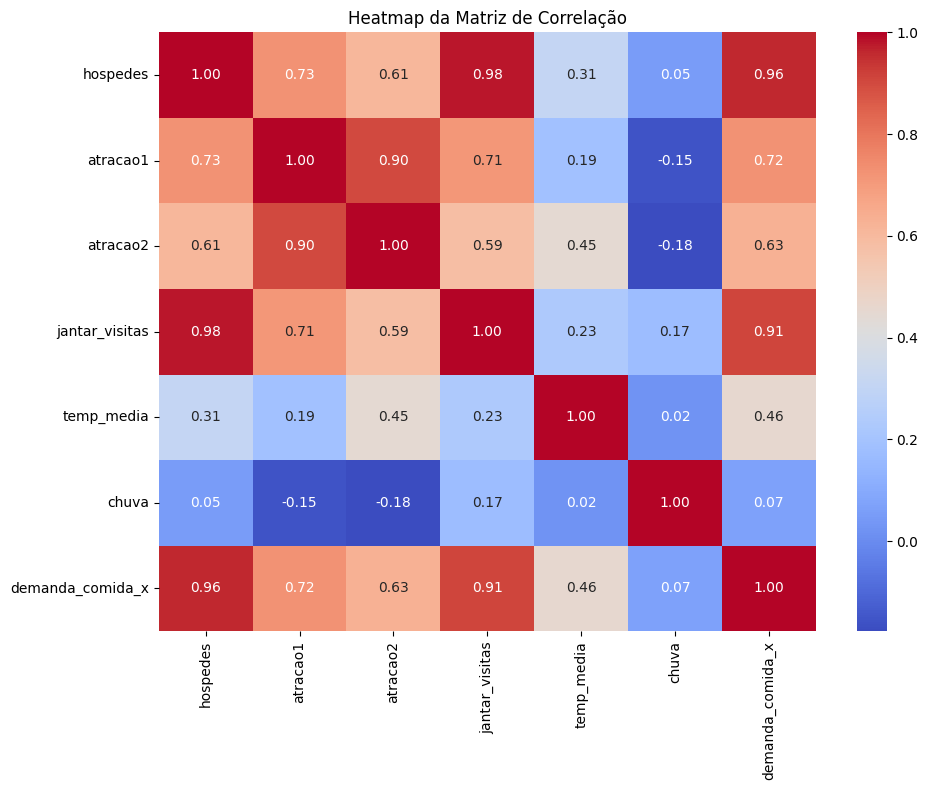

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap da Matriz de Correlação')
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   The correlation matrix for the numeric columns of the DataFrame `df` was successfully calculated and displayed.
*   A heatmap of the correlation matrix was generated and visualized using `seaborn` and `matplotlib.pyplot`.
*   The heatmap displays the correlation values between numeric variables, formatted to two decimal places and annotated on the plot.

### Insights or Next Steps

*   Analyze the heatmap to identify strong positive and negative correlations between variables, which could indicate relationships or multicollinearity.
*   Based on the observed correlations, consider feature selection or transformation techniques if necessary for subsequent modeling tasks.


In [ ]:
# separando os dados pelo tipo de hotel:

df_praia = df[df['hotel_tipo'] == 'praia']
df_fazenda = df[df['hotel_tipo'] == 'fazenda']

In [ ]:
# separando conjunto de treinamento e conjunto de testes para as regressões e xgbooster:

from sklearn.model_selection import train_test_split

# vamos introduzir senos e cossenos para capturar a sazonalidade e tratar as variáveis:

df_praia['data'] = pd.to_datetime(df_praia['data'])
dia_ano_praia = np.array(df_praia['data'].dt.dayofyear)
df_praia['seno_dia_ano'] = np.sin(2 * np.pi * dia_ano_praia / 365)
df_praia['cosseno_dia_ano'] = np.cos(2 * np.pi * dia_ano_praia / 365)

X_praia = df_praia.drop(columns=['data', 'hotel_tipo', 'jantar_visitas', 'demanda_comida_x'])
y_praia = df_praia['demanda_comida_x']

df_fazenda['data'] = pd.to_datetime(df_fazenda['data'])
dia_ano_fazenda = np.array(df_fazenda['data'].dt.dayofyear)
df_fazenda['seno_dia_ano'] = np.sin(2 * np.pi * dia_ano_fazenda / 366) # considerando ano bissexto
df_fazenda['cosseno_dia_ano'] = np.cos(2 * np.pi * dia_ano_fazenda / 366) # considerando ano bissexto

X_fazenda = df_fazenda.drop(columns=['data', 'hotel_tipo', 'jantar_visitas', 'demanda_comida_x'])
y_fazenda = df_fazenda['demanda_comida_x']


X_train_praia, X_test_praia, y_train_praia, y_test_praia = train_test_split(X_praia, y_praia, test_size=0.2, random_state=0)
X_train_fazenda, X_test_fazenda, y_train_fazenda, y_test_fazenda = train_test_split(X_fazenda, y_fazenda, test_size=0.2, random_state=0)

/tmp/ipython-input-3093040077.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_praia['data'] = pd.to_datetime(df_praia['data'])
/tmp/ipython-input-3093040077.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_praia['seno_dia_ano'] = np.sin(2 * np.pi * dia_ano_praia / 365)
/tmp/ipython-input-3093040077.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

In [ ]:
# agora vamos treinar uma regressão linear, uma regressão logística, uma árvore de regressão e um xgboost:

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

linear_model_praia = LinearRegression()
linear_model_praia.fit(X_train_praia, y_train_praia)

logistic_model_praia = LogisticRegression()
logistic_model_praia.fit(X_train_praia, y_train_praia)

tree_model_praia = DecisionTreeRegressor()
tree_model_praia.fit(X_train_praia, y_train_praia)

xgb_model_praia = XGBRegressor()
xgb_model_praia = xgb_model_praia.fit(X_train_praia, y_train_praia)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# vamos fazer o mesmo para a fazenda:

linear_model_fazenda = LinearRegression()
linear_model_fazenda.fit(X_train_fazenda, y_train_fazenda)

logistic_model_fazenda = LogisticRegression()
logistic_model_fazenda.fit(X_train_fazenda, y_train_fazenda)

tree_model_fazenda = DecisionTreeRegressor()
tree_model_fazenda.fit(X_train_fazenda, y_train_fazenda)

xgb_model_fazenda = XGBRegressor()
xgb_model_fazenda = xgb_model_fazenda.fit(X_train_fazenda, y_train_fazenda)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# vamos agora verificar as métricas de performance para a praia e para a fazenda

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Métricas para os modelos de praia
y_pred_linear_praia = linear_model_praia.predict(X_test_praia)
y_pred_tree_praia = tree_model_praia.predict(X_test_praia)
y_pred_xgb_praia = xgb_model_praia.predict(X_test_praia)

rmse_linear_praia = mean_squared_error(y_test_praia, y_pred_linear_praia)
mae_linear_praia = mean_absolute_error(y_test_praia, y_pred_linear_praia)
r2_linear_praia = r2_score(y_test_praia, y_pred_linear_praia)

rmse_tree_praia = mean_squared_error(y_test_praia, y_pred_tree_praia)
mae_tree_praia = mean_absolute_error(y_test_praia, y_pred_tree_praia)
r2_tree_praia = r2_score(y_test_praia, y_pred_tree_praia)

rmse_xgb_praia = mean_squared_error(y_test_praia, y_pred_xgb_praia)
mae_xgb_praia = mean_absolute_error(y_test_praia, y_pred_xgb_praia)
r2_xgb_praia = r2_score(y_test_praia, y_pred_xgb_praia)

# Métricas para os modelos de fazenda
y_pred_linear_fazenda = linear_model_fazenda.predict(X_test_fazenda)
y_pred_tree_fazenda = tree_model_fazenda.predict(X_test_fazenda)
y_pred_xgb_fazenda = xgb_model_fazenda.predict(X_test_fazenda)

rmse_linear_fazenda = mean_squared_error(y_test_fazenda, y_pred_linear_fazenda)
mae_linear_fazenda = mean_absolute_error(y_test_fazenda, y_pred_linear_fazenda)
r2_linear_fazenda = r2_score(y_test_fazenda, y_pred_linear_fazenda)

rmse_tree_fazenda = mean_squared_error(y_test_fazenda, y_pred_tree_fazenda)
mae_tree_fazenda = mean_absolute_error(y_test_fazenda, y_pred_tree_fazenda)
r2_tree_fazenda = r2_score(y_test_fazenda, y_pred_tree_fazenda)

rmse_xgb_fazenda = mean_squared_error(y_test_fazenda, y_pred_xgb_fazenda)
mae_xgb_fazenda = mean_absolute_error(y_test_fazenda, y_pred_xgb_fazenda)
r2_xgb_fazenda = r2_score(y_test_fazenda, y_pred_xgb_fazenda)

In [ ]:
print("Performance Metrics - Praia Hotel:")
print(f"Linear Regression: RMSE={rmse_linear_praia:.2f}, MAE={mae_linear_praia:.2f}, R2={r2_linear_praia:.2f}")
print(f"Decision Tree Regressor: RMSE={rmse_tree_praia:.2f}, MAE={mae_tree_praia:.2f}, R2={r2_tree_praia:.2f}")
print(f"XGBoost Regressor: RMSE={rmse_xgb_praia:.2f}, MAE={mae_xgb_praia:.2f}, R2={r2_xgb_praia:.2f}")
print("-" * 30)
print("Performance Metrics - Fazenda Hotel:")
print(f"Linear Regression: RMSE={rmse_linear_fazenda:.2f}, MAE={mae_linear_fazenda:.2f}, R2={r2_linear_fazenda:.2f}")
print(f"Decision Tree Regressor: RMSE={rmse_tree_fazenda:.2f}, MAE={mae_tree_fazenda:.2f}, R2={r2_tree_fazenda:.2f}")
print(f"XGBoost Regressor: RMSE={rmse_xgb_fazenda:.2f}, MAE={mae_xgb_fazenda:.2f}, R2={r2_xgb_fazenda:.2f}")

Performance Metrics - Praia Hotel:
Linear Regression: RMSE=7.89, MAE=2.02, R2=1.00
Decision Tree Regressor: RMSE=45.03, MAE=4.43, R2=0.98
XGBoost Regressor: RMSE=27.24, MAE=3.40, R2=0.99
------------------------------
Performance Metrics - Fazenda Hotel:
Linear Regression: RMSE=5.94, MAE=1.96, R2=0.99
Decision Tree Regressor: RMSE=23.78, MAE=3.57, R2=0.96
XGBoost Regressor: RMSE=12.48, MAE=2.72, R2=0.98


### Validação Cruzada para o Modelo de Regressão Linear (Praia)

Para verificar a robustez do modelo e diagnosticar possível overfitting, realizaremos validação cruzada. Usaremos o `KFold` para dividir os dados de treinamento em 5 folds.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

# Usaremos 5 folds para a validação cruzada
kf = KFold(n_splits=5, shuffle=True, random_state=0)

# Avaliando a performance do modelo de Regressão Linear nos dados de treino da praia usando validação cruzada
# Usaremos 'neg_mean_squared_error' como métrica e depois converteremos para RMSE
cv_scores_mse = cross_val_score(linear_model_praia, X_train_praia, y_train_praia, cv=kf, scoring='neg_mean_squared_error')

# Convertendo MSE negativo para RMSE
cv_scores_rmse = np.sqrt(-cv_scores_mse)

print("RMSEs da Validação Cruzada para Linear Regression (Praia):", cv_scores_rmse)
print("RMSE Médio da Validação Cruzada:", cv_scores_rmse.mean())

RMSEs da Validação Cruzada para Linear Regression (Praia): [3.54175986 3.49181987 2.96153595 2.73993656 3.50925886]
RMSE Médio da Validação Cruzada: 3.248862218987246


### Validação Cruzada para outros Modelos (Praia e Fazenda)

In [ ]:
# Validação cruzada para Decision Tree Regressor (Praia)
cv_scores_mse_tree_praia = cross_val_score(tree_model_praia, X_train_praia, y_train_praia, cv=kf, scoring='neg_mean_squared_error')
cv_scores_rmse_tree_praia = np.sqrt(-cv_scores_mse_tree_praia)

print("RMSEs da Validação Cruzada para Decision Tree Regressor (Praia):", cv_scores_rmse_tree_praia)
print("RMSE Médio da Validação Cruzada (Decision Tree Regressor - Praia):", cv_scores_rmse_tree_praia.mean())
print("-" * 30)

# Validação cruzada para XGBoost Regressor (Praia)
cv_scores_mse_xgb_praia = cross_val_score(xgb_model_praia, X_train_praia, y_train_praia, cv=kf, scoring='neg_mean_squared_error')
cv_scores_rmse_xgb_praia = np.sqrt(-cv_scores_mse_xgb_praia)

print("RMSEs da Validação Cruzada para XGBoost Regressor (Praia):", cv_scores_rmse_xgb_praia)
print("RMSE Médio da Validação Cruzada (XGBoost Regressor - Praia):", cv_scores_rmse_xgb_praia.mean())
print("-" * 30)

# Validação cruzada para Linear Regression (Fazenda)
cv_scores_mse_linear_fazenda = cross_val_score(linear_model_fazenda, X_train_fazenda, y_train_fazenda, cv=kf, scoring='neg_mean_squared_error')
cv_scores_rmse_linear_fazenda = np.sqrt(-cv_scores_mse_linear_fazenda)

print("RMSEs da Validação Cruzada para Linear Regression (Fazenda):", cv_scores_rmse_linear_fazenda)
print("RMSE Médio da Validação Cruzada (Linear Regression - Fazenda):", cv_scores_rmse_linear_fazenda.mean())
print("-" * 30)

# Validação cruzada para Decision Tree Regressor (Fazenda)
cv_scores_mse_tree_fazenda = cross_val_score(tree_model_fazenda, X_train_fazenda, y_train_fazenda, cv=kf, scoring='neg_mean_squared_error')
cv_scores_rmse_tree_fazenda = np.sqrt(-cv_scores_mse_tree_fazenda)

print("RMSEs da Validação Cruzada para Decision Tree Regressor (Fazenda):", cv_scores_rmse_tree_fazenda)
print("RMSE Médio da Validação Cruzada (Decision Tree Regressor - Fazenda):", cv_scores_rmse_tree_fazenda.mean())
print("-" * 30)

# Validação cruzada para XGBoost Regressor (Fazenda)
cv_scores_mse_xgb_fazenda = cross_val_score(xgb_model_fazenda, X_train_fazenda, y_train_fazenda, cv=kf, scoring='neg_mean_squared_error')
cv_scores_rmse_xgb_fazenda = np.sqrt(-cv_scores_mse_xgb_fazenda)

print("RMSEs da Validação Cruzada para XGBoost Regressor (Fazenda):", cv_scores_rmse_xgb_fazenda)
print("RMSE Médio da Validação Cruzada (XGBoost Regressor - Fazenda):", cv_scores_rmse_xgb_fazenda.mean())

RMSEs da Validação Cruzada para Decision Tree Regressor (Praia): [5.92609855 6.00564706 5.86338728 7.28366145 5.38356375]
RMSE Médio da Validação Cruzada (Decision Tree Regressor - Praia): 6.092471617608655
------------------------------
RMSEs da Validação Cruzada para XGBoost Regressor (Praia): [3.67361072 4.27914711 4.05553109 4.54032673 4.13845573]
RMSE Médio da Validação Cruzada (XGBoost Regressor - Praia): 4.137414273406695
------------------------------
RMSEs da Validação Cruzada para Linear Regression (Fazenda): [2.47481691 2.50266991 2.29412478 2.09440167 2.39169656]
RMSE Médio da Validação Cruzada (Linear Regression - Fazenda): 2.35154196589529
------------------------------
RMSEs da Validação Cruzada para Decision Tree Regressor (Fazenda): [4.46454963 3.95740028 4.78142959 4.15019734 5.70390066]
RMSE Médio da Validação Cruzada (Decision Tree Regressor - Fazenda): 4.611495499604905
------------------------------
RMSEs da Validação Cruzada para XGBoost Regressor (Fazenda): [3.6

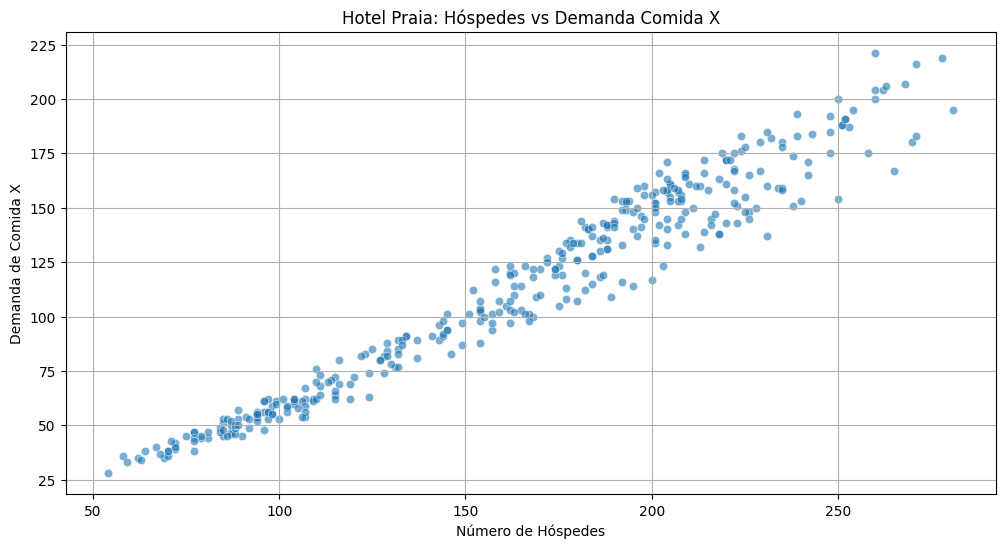

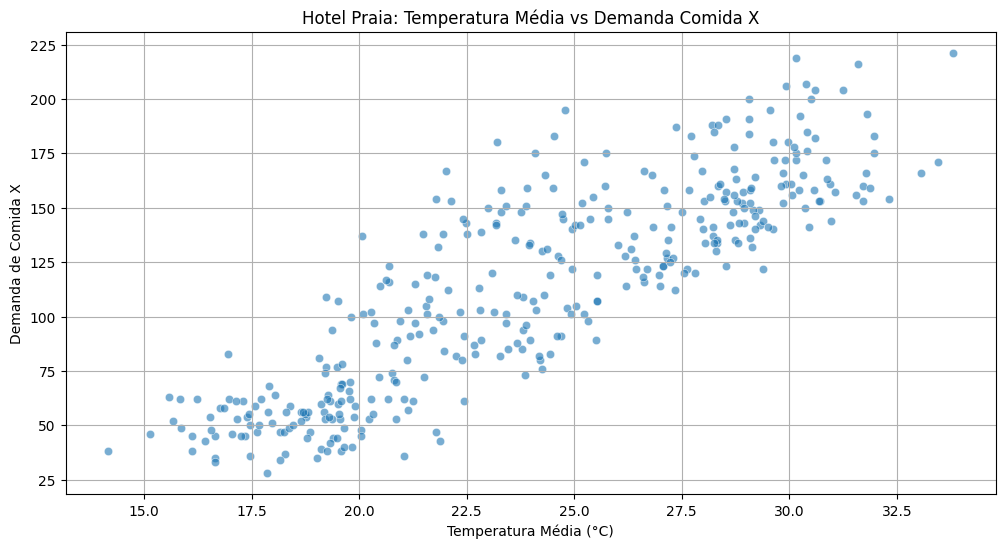

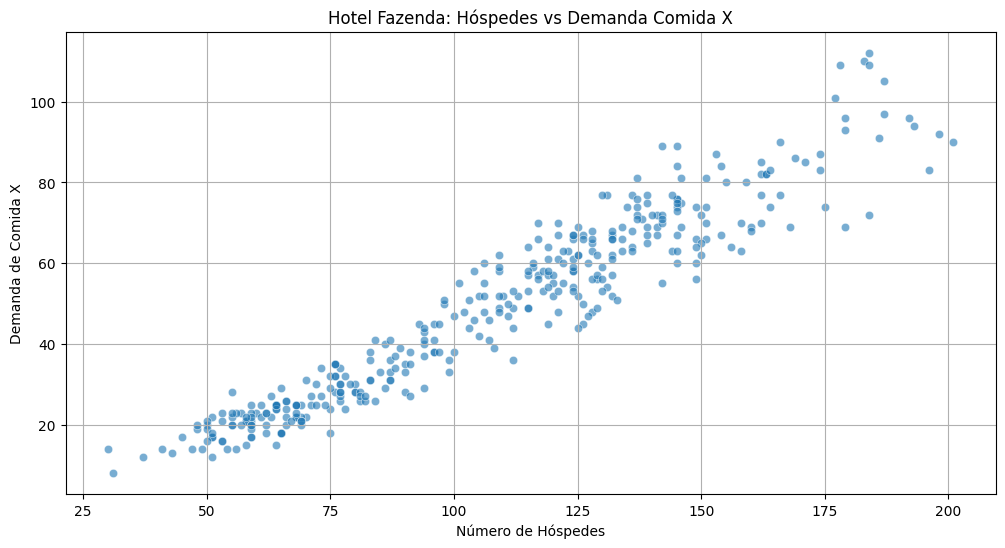

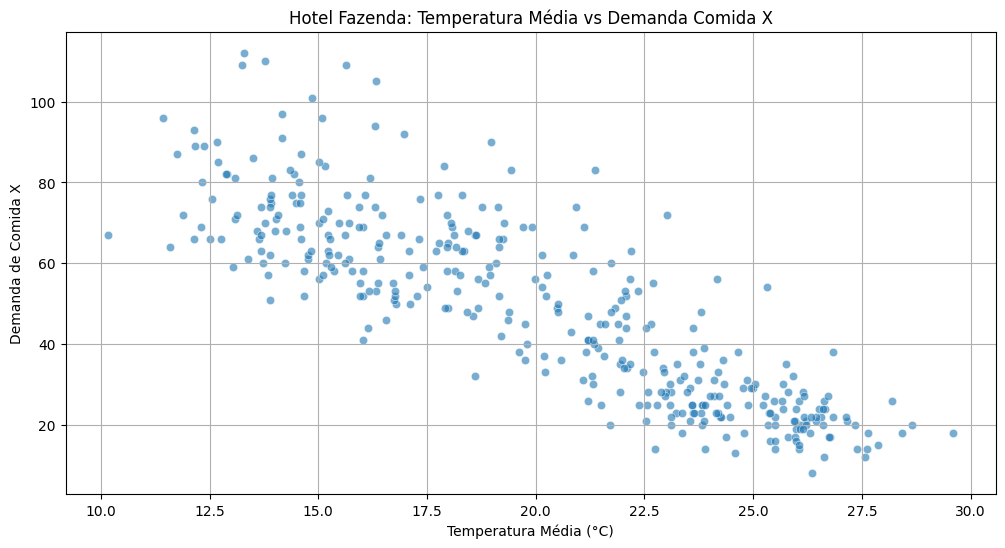

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico para Hotel Praia - Hospedes vs Demanda Comida X
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_praia, x='hospedes', y='demanda_comida_x', alpha=0.6)
plt.title('Hotel Praia: Hóspedes vs Demanda Comida X')
plt.xlabel('Número de Hóspedes')
plt.ylabel('Demanda de Comida X')
plt.grid(True)
plt.show()

# Gráfico para Hotel Praia - Temperatura Média vs Demanda Comida X
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_praia, x='temp_media', y='demanda_comida_x', alpha=0.6)
plt.title('Hotel Praia: Temperatura Média vs Demanda Comida X')
plt.xlabel('Temperatura Média (°C)')
plt.ylabel('Demanda de Comida X')
plt.grid(True)
plt.show()

# Gráfico para Hotel Fazenda - Hospedes vs Demanda Comida X
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_fazenda, x='hospedes', y='demanda_comida_x', alpha=0.6)
plt.title('Hotel Fazenda: Hóspedes vs Demanda Comida X')
plt.xlabel('Número de Hóspedes')
plt.ylabel('Demanda de Comida X')
plt.grid(True)
plt.show()

# Gráfico para Hotel Fazenda - Temperatura Média vs Demanda Comida X
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_fazenda, x='temp_media', y='demanda_comida_x', alpha=0.6)
plt.title('Hotel Fazenda: Temperatura Média vs Demanda Comida X')
plt.xlabel('Temperatura Média (°C)')
plt.ylabel('Demanda de Comida X')
plt.grid(True)
plt.show()


Resumo (últimos 90 dias):
  hotel  total_opt  total_model  total_naive  regret_model  regret_naive  wasted_model_money  wasted_naive_money  shortage_model_units  shortage_naive_units  mae_model
fazenda   31260.00     33001.00     47003.00       1741.00      15743.00             1265.00                0.00                    68                  2249       3.25
  praia   31715.00     35130.00     60600.00       3415.00      28885.00             3310.00            28885.00                    15                     0       4.76


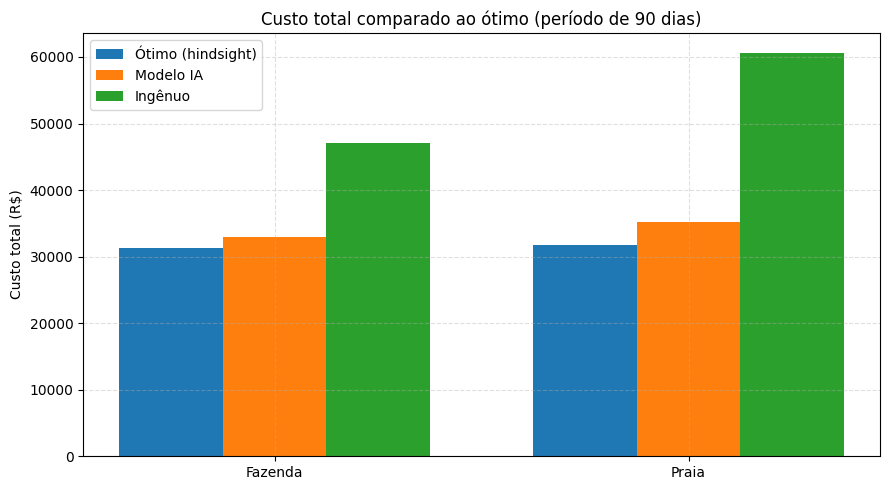

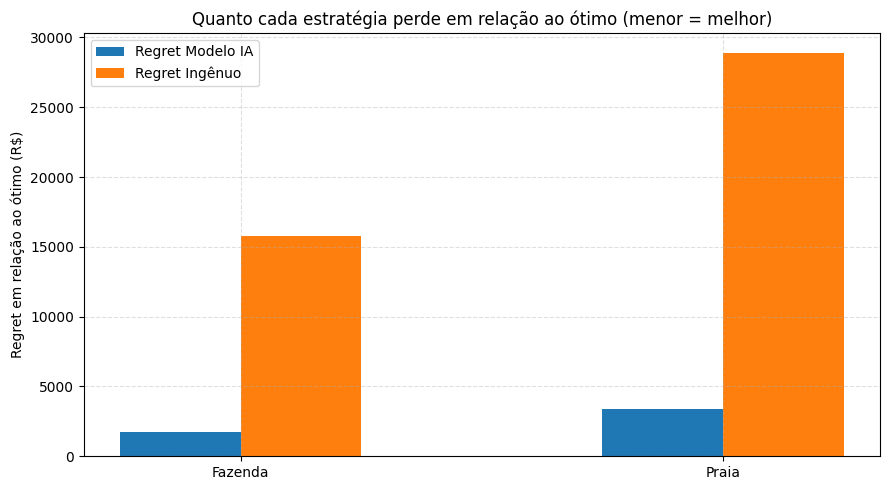


Dica rápida: se o modelo gera faltas, aumente SAFETY_MARGIN ou use previsão de quantil (newsvendor) com fractil crítico = shortage_penalty / (shortage_penalty + COST_PER_UNIT).


In [ ]:
# compara_com_otimo.py
# Requisitos: pandas, numpy, matplotlib, xgboost, scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

CSV_PATH = "dados_sinteticos_hoteis.csv"  # ajuste se necessário
TEST_DAYS = 90
COST_PER_UNIT = 5.0        # R$ por porção comprada
SHORTAGE_PENALTY = 12.0    # R$ por porção em falta
SAFETY_MARGIN = 0.05       # margem aplicada às previsões do modelo (pode calibrar)

# carregar e preparar features
df = pd.read_csv(CSV_PATH, parse_dates=["data"]).sort_values("data")
df["dia_ano"] = df["data"].dt.dayofyear
df["sin_dia_ano"] = np.sin(2 * np.pi * df["dia_ano"] / 365.0)
df["cos_dia_ano"] = np.cos(2 * np.pi * df["dia_ano"] / 365.0)
df["weekday"] = df["data"].dt.weekday
df["is_weekend"] = (df["weekday"] >= 5).astype(int)
df["month"] = df["data"].dt.month

feature_cols = [
    "hospedes", "atracao1", "atracao2", "jantar_visitas",
    "temp_media", "chuva", "sin_dia_ano", "cos_dia_ano", "is_weekend", "month"
]

def simulate_costs(purchased, actual, cost_unit=COST_PER_UNIT, shortage_penalty=SHORTAGE_PENALTY):
    purchased = np.array(purchased)
    actual = np.array(actual)
    wasted = np.maximum(0, purchased - actual)
    shortage = np.maximum(0, actual - purchased)
    purchase_cost = purchased * cost_unit
    shortage_cost = shortage * shortage_penalty
    total_cost = purchase_cost + shortage_cost
    return {
        "purchased": purchased,
        "actual": actual,
        "wasted": wasted,
        "shortage": shortage,
        "purchase_cost": purchase_cost,
        "shortage_cost": shortage_cost,
        "total_cost": total_cost
    }

summary = []

for hotel in df["hotel_tipo"].unique():
    d = df[df["hotel_tipo"] == hotel].copy().reset_index(drop=True)
    train = d.iloc[:-TEST_DAYS]
    test = d.iloc[-TEST_DAYS:]
    X_train = train[feature_cols]; y_train = train["demanda_comida_x"]
    X_test = test[feature_cols]; y_test = test["demanda_comida_x"].values

    # treinar modelo XGBoost (padrao)
    model = XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    preds = np.maximum(preds, 0)

    # baseline ingênuo: média por weekday do treino
    avg_by_weekday = train.groupby("weekday")["demanda_comida_x"].mean().to_dict()
    naive_preds = test["weekday"].map(avg_by_weekday).values
    naive_preds = np.nan_to_num(naive_preds, nan=y_train.mean())

    # quantidade comprada (aplicando margem em ambas)
    purchased_model = np.ceil(preds * (1 + SAFETY_MARGIN)).astype(int)
    purchased_naive = np.ceil(naive_preds * (1 + SAFETY_MARGIN)).astype(int)

    # solução ideal (hindsight): comprar exatamente o real (sem desperdício, sem falta)
    purchased_optimal = y_test.astype(int)

    # simular custos
    sim_model = simulate_costs(purchased_model, y_test)
    sim_naive = simulate_costs(purchased_naive, y_test)
    sim_opt = simulate_costs(purchased_optimal, y_test)

    total_model = sim_model["total_cost"].sum()
    total_naive = sim_naive["total_cost"].sum()
    total_opt = sim_opt["total_cost"].sum()  # normalmente = consumo * COST_PER_UNIT

    # resumo de desperdício / falta
    wasted_model_money = sim_model["wasted"].sum() * COST_PER_UNIT
    wasted_naive_money = sim_naive["wasted"].sum() * COST_PER_UNIT
    shortage_model_units = sim_model["shortage"].sum()
    shortage_naive_units = sim_naive["shortage"].sum()

    summary.append({
        "hotel": hotel,
        "total_opt": total_opt,
        "total_model": total_model,
        "total_naive": total_naive,
        "wasted_model_money": wasted_model_money,
        "wasted_naive_money": wasted_naive_money,
        "shortage_model_units": int(shortage_model_units),
        "shortage_naive_units": int(shortage_naive_units),
        "mae_model": mean_absolute_error(y_test, preds)
    })

# montar DataFrame e imprimir
sum_df = pd.DataFrame(summary)
sum_df["regret_model"] = sum_df["total_model"] - sum_df["total_opt"]
sum_df["regret_naive"] = sum_df["total_naive"] - sum_df["total_opt"]
sum_df = sum_df.sort_values("hotel").reset_index(drop=True)

print("\nResumo (últimos {} dias):".format(TEST_DAYS))
print(sum_df[["hotel","total_opt","total_model","total_naive","regret_model","regret_naive",
              "wasted_model_money","wasted_naive_money","shortage_model_units","shortage_naive_units","mae_model"]].to_string(index=False, float_format='%.2f'))

# ---- Gráfico 1: custos absolutos (Ótimo vs Modelo vs Ingênuo) ----
labels = [h.capitalize() for h in sum_df["hotel"]]
x = np.arange(len(labels))
width = 0.25

opt = sum_df["total_opt"].values
mod = sum_df["total_model"].values
nai = sum_df["total_naive"].values

plt.figure(figsize=(9,5))
plt.bar(x - width, opt, width, label="Ótimo (hindsight)")
plt.bar(x, mod, width, label="Modelo IA")
plt.bar(x + width, nai, width, label="Ingênuo")
plt.xticks(x, labels)
plt.ylabel("Custo total (R$)")
plt.title(f"Custo total comparado ao ótimo (período de {TEST_DAYS} dias)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ---- Gráfico 2: Regret (diferença para o ótimo) ----
reg_model = sum_df["regret_model"].values
reg_naive = sum_df["regret_naive"].values

plt.figure(figsize=(9,5))
plt.bar(x - width/2, reg_model, width, label="Regret Modelo IA")
plt.bar(x + width/2, reg_naive, width, label="Regret Ingênuo")
plt.xticks(x, labels)
plt.ylabel("Regret em relação ao ótimo (R$)")
plt.title("Quanto cada estratégia perde em relação ao ótimo (menor = melhor)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Observações -> dicas para corrigir faltas
for _, row in sum_df.iterrows():
    if row["shortage_model"] if "shortage_model" in row.index else row["shortage_model_units"]:
        pass  # placeholder

print("\nDica rápida: se o modelo gera faltas, aumente SAFETY_MARGIN ou use previsão de quantil (newsvendor) com fractil crítico = shortage_penalty / (shortage_penalty + COST_PER_UNIT).")


In [ ]:
# Aplicar média móvel para suavizar
df_group["hospedes_smooth"] = df_group.groupby("hotel_tipo")["hospedes"].transform(lambda x: x.rolling(window=7, center=True).mean())

# Criar gráfico suavizado
plt.figure(figsize=(12, 6))
for hotel in df_group["hotel_tipo"].unique():
    subset = df_group[df_group["hotel_tipo"] == hotel]
    plt.plot(subset["data"], subset["hospedes_smooth"], label=hotel.capitalize())

plt.title("Número de hóspedes ao longo do ano por tipo de hotel (suavizado)")
plt.xlabel("Data")
plt.ylabel("Número de hóspedes (média móvel 7 dias)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


NameError: name 'df_group' is not defined

In [ ]:
# exporta_medias_movel_e_dados_barras.py
# Requer: pandas, numpy, xgboost, scikit-learn
# Ajuste CSV_PATH se necessário.

import os
import pandas as pd
import numpy as np
from math import ceil

try:
    from xgboost import XGBRegressor
except Exception as e:
    raise RuntimeError("xgboost não encontrado. Instale com: pip install xgboost") from e

# ---------- parâmetros (ajuste conforme necessário) ----------
CSV_PATH = "dados_sinteticos_hoteis.csv"
OUT_DIR = "./export_canva"   # diretório onde os CSVs serão salvos
TEST_DAYS = 90
MA_WINDOW = 7                # janela média móvel (dias)
COST_PER_UNIT = 5.0          # preço por porção (R$)
SHORTAGE_PENALTY = 12.0      # custo por porção em falta (R$) - usado apenas para custos totais
SAFETY_MARGIN = 0.05         # margem aplicada sobre previsão do modelo e baseline (pode calibrar)
# ----------------------------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)

# carregar e ordenar
df = pd.read_csv(CSV_PATH, parse_dates=["data"])
df = df.sort_values("data").reset_index(drop=True)

# médias móveis por hotel (hóspedes e demanda)
for hotel in df["hotel_tipo"].unique():
    d = df[df["hotel_tipo"] == hotel].copy().sort_values("data").reset_index(drop=True)
    d = d.set_index("data")
    # média móvel centrada (min_periods=1 para evitar NaNs nas bordas)
    d["hospedes_ma"] = d["hospedes"].rolling(window=MA_WINDOW, center=True, min_periods=1).mean().round(2)
    d["demanda_ma"] = d["demanda_comida_x"].rolling(window=MA_WINDOW, center=True, min_periods=1).mean().round(2)
    out_path = os.path.join(OUT_DIR, f"moving_avg_{hotel}.csv")
    d.reset_index()[["data", "hotel_tipo", "hospedes", "hospedes_ma", "demanda_comida_x", "demanda_ma"]].to_csv(out_path, index=False)
    print(f"Salvou médias móveis: {out_path}")

# preparar features comuns
df["dia_ano"] = df["data"].dt.dayofyear
df["sin_dia_ano"] = np.sin(2 * np.pi * df["dia_ano"] / 365.0)
df["cos_dia_ano"] = np.cos(2 * np.pi * df["dia_ano"] / 365.0)
df["weekday"] = df["data"].dt.weekday
df["is_weekend"] = (df["weekday"] >= 5).astype(int)
df["month"] = df["data"].dt.month

feature_cols = [
    "hospedes", "atracao1", "atracao2", "jantar_visitas",
    "temp_media", "chuva", "sin_dia_ano", "cos_dia_ano", "is_weekend", "month"
]

agg_rows = []

def simulate_costs_array(purchased, actual, cost_unit=COST_PER_UNIT, shortage_penalty=SHORTAGE_PENALTY):
    purchased = np.array(purchased, dtype=float)
    actual = np.array(actual, dtype=float)
    wasted = np.maximum(0, purchased - actual)
    shortage = np.maximum(0, actual - purchased)
    purchase_cost = purchased * cost_unit
    shortage_cost = shortage * shortage_penalty
    total_cost = purchase_cost + shortage_cost
    return {
        "purchased": purchased,
        "actual": actual,
        "wasted": wasted,
        "shortage": shortage,
        "purchase_cost": purchase_cost,
        "shortage_cost": shortage_cost,
        "total_cost": total_cost
    }

# para cada hotel: treinar, prever, simular e salvar CSV diário
for hotel in df["hotel_tipo"].unique():
    d = df[df["hotel_tipo"] == hotel].copy().reset_index(drop=True)
    if len(d) <= TEST_DAYS + 10:
        raise RuntimeError(f"Dados insuficientes para o hotel '{hotel}' com TEST_DAYS={TEST_DAYS}")

    train = d.iloc[:-TEST_DAYS]
    test = d.iloc[-TEST_DAYS:].copy().reset_index(drop=True)

    X_train = train[feature_cols]
    y_train = train["demanda_comida_x"]
    X_test = test[feature_cols]
    y_test = test["demanda_comida_x"].values

    # treinar XGBoost (config simples)
    model = XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
    model.fit(X_train, y_train)

    # previsões do modelo
    preds = model.predict(X_test)
    preds = np.maximum(preds, 0)

    # baseline ingênuo = média histórica por weekday no treino
    avg_by_weekday = train.groupby("weekday")["demanda_comida_x"].mean().to_dict()
    naive_preds = test["weekday"].map(avg_by_weekday).values
    naive_preds = np.nan_to_num(naive_preds, nan=y_train.mean())

    # quantidades que seriam compradas (aplicando margem)
    purchased_model = np.ceil(preds * (1 + SAFETY_MARGIN)).astype(int)
    purchased_naive = np.ceil(naive_preds * (1 + SAFETY_MARGIN)).astype(int)
    purchased_optimal = y_test.astype(int)  # hindsight: comprar exatamente o real

    # simular custos diários
    sim_model = simulate_costs_array(purchased_model, y_test)
    sim_naive = simulate_costs_array(purchased_naive, y_test)
    sim_opt = simulate_costs_array(purchased_optimal, y_test)

    # construir DataFrame diário com tudo que pode ser útil para os gráficos
    df_sim = pd.DataFrame({
        "data": test["data"],
        "hotel_tipo": hotel,
        "actual_demand": sim_model["actual"].astype(int),
        "purchased_model": sim_model["purchased"].astype(int),
        "purchased_naive": sim_naive["purchased"].astype(int),
        "purchased_optimal": sim_opt["purchased"].astype(int),
        "wasted_model_units": sim_model["wasted"].astype(int),
        "wasted_naive_units": sim_naive["wasted"].astype(int),
        "shortage_model_units": sim_model["shortage"].astype(int),
        "shortage_naive_units": sim_naive["shortage"].astype(int),
        "purchase_cost_model": sim_model["purchase_cost"],
        "purchase_cost_naive": sim_naive["purchase_cost"],
        "purchase_cost_opt": sim_opt["purchase_cost"],
        "shortage_cost_model": sim_model["shortage_cost"],
        "shortage_cost_naive": sim_naive["shortage_cost"],
        "total_cost_model": sim_model["total_cost"],
        "total_cost_naive": sim_naive["total_cost"],
        "total_cost_opt": sim_opt["total_cost"],
    })

    # salvar csv diário (usável para gráficos de barra empilhada ou série temporal)
    out_daily = os.path.join(OUT_DIR, f"sim_{hotel}.csv")
    df_sim.to_csv(out_daily, index=False)
    print(f"Salvou simulação diária: {out_daily}")

    # agregar para dados do gráfico de barras (valores totais no período de teste)
    total_model = df_sim["total_cost_model"].sum()
    total_naive = df_sim["total_cost_naive"].sum()
    total_opt = df_sim["total_cost_opt"].sum()
    wasted_model_money = df_sim["wasted_model_units"].sum() * COST_PER_UNIT
    wasted_naive_money = df_sim["wasted_naive_units"].sum() * COST_PER_UNIT
    actual_consumed_money = df_sim["actual_demand"].sum() * COST_PER_UNIT
    savings_waste_money = wasted_naive_money - wasted_model_money
    regret_model = total_model - total_opt
    regret_naive = total_naive - total_opt

    agg_rows.append({
        "hotel": hotel,
        "test_days": TEST_DAYS,
        "total_cost_opt": total_opt,
        "total_cost_model": total_model,
        "total_cost_naive": total_naive,
        "wasted_model_money": wasted_model_money,
        "wasted_naive_money": wasted_naive_money,
        "actual_consumed_money": actual_consumed_money,
        "savings_waste_money": savings_waste_money,
        "regret_model": regret_model,
        "regret_naive": regret_naive,
        "shortage_model_units": int(df_sim["shortage_model_units"].sum()),
        "shortage_naive_units": int(df_sim["shortage_naive_units"].sum()),
    })

# salvar CSV agregado para gráfico de barras
bar_df = pd.DataFrame(agg_rows).sort_values("hotel").reset_index(drop=True)
out_bar = os.path.join(OUT_DIR, "bar_chart_data.csv")
bar_df.to_csv(out_bar, index=False)
print(f"Salvou dados agregados para barras: {out_bar}")

print("\nArquivos gerados no diretório:", os.path.abspath(OUT_DIR))
print("Principais arquivos:\n - moving_avg_<hotel>.csv\n - sim_<hotel>.csv  (dados diários para gráficos)\n - bar_chart_data.csv (dados agregados por hotel para barras)\n")


Salvou médias móveis: ./export_canva/moving_avg_praia.csv
Salvou médias móveis: ./export_canva/moving_avg_fazenda.csv
Salvou simulação diária: ./export_canva/sim_praia.csv
Salvou simulação diária: ./export_canva/sim_fazenda.csv
Salvou dados agregados para barras: ./export_canva/bar_chart_data.csv

Arquivos gerados no diretório: /content/export_canva
Principais arquivos:
 - moving_avg_<hotel>.csv
 - sim_<hotel>.csv  (dados diários para gráficos)
 - bar_chart_data.csv (dados agregados por hotel para barras)



In [ ]:
import pandas as pd
import numpy as np

# Exemplo: dataframe original
# df deve ter pelo menos a coluna 'Date' e 'Price'
# df = pd.read_csv("dados.csv", parse_dates=["Date"])

# Exemplo de criação fictícia (remova se já tiver o df)
date_rng = pd.date_range(start="2024-01-01", end="2024-03-31", freq="D")
df = pd.DataFrame({"Date": date_rng, "Price": np.random.uniform(100, 200, len(date_rng))})

# Cálculo das médias móveis
df["MA_7"] = df["Price"].rolling(window=7).mean()
df["MA_30"] = df["Price"].rolling(window=30).mean()

# Exemplo de dados para gráfico de barras (pode ser volume, P&L, etc.)
# Aqui só um valor fictício: diferença percentual diária
df["Daily_Change_%"] = df["Price"].pct_change() * 100

# OPCIONAL: reduzir datas no CSV
# (mostra apenas linhas a cada 7 dias)
reduzir_datas = True
if reduzir_datas:
    df = df.iloc[::7, :]

# Exporta tudo para um único CSV
df.to_csv("dados_unificados.csv", index=False)

print("Arquivo 'dados_unificados.csv' gerado com sucesso!")


Arquivo 'dados_unificados.csv' gerado com sucesso!


In [ ]:
import pandas as pd
import numpy as np

# Gerando dados fictícios para 5 anos (por exemplo)
np.random.seed(42)
dias = pd.date_range(start="2020-01-01", periods=365, freq="D")
praia = np.random.uniform(20, 35, len(dias))  # valores aleatórios
fazenda = np.random.uniform(15, 30, len(dias))

# Criando DataFrame
df = pd.DataFrame({
    "data": dias,
    "praia": praia,
    "fazenda": fazenda
})

# Calculando médias móveis de 365 dias
df["ma_praia"] = df["praia"].rolling(window=365).mean()
df["ma_fazenda"] = df["fazenda"].rolling(window=365).mean()

# Mantendo apenas as duas colunas de interesse
df_out = df[["ma_praia", "ma_fazenda"]]

# Salvando em CSV
df_out.to_csv("medias_moveis_365.csv", index=False)

print("Arquivo CSV gerado: medias_moveis_365.csv")


Arquivo CSV gerado: medias_moveis_365.csv


DataFrame com 365 amostras exportado com sucesso para 'medias_moveis_suavizadas.csv'
hotel_tipo  ma_fazenda   ma_praia
data                             
2024-01-01   49.356478  69.368744
2024-01-02   48.755099  70.149884
2024-01-03   48.173791  70.516400
2024-01-04   47.636813  71.624149
2024-01-05   47.342262  72.741434


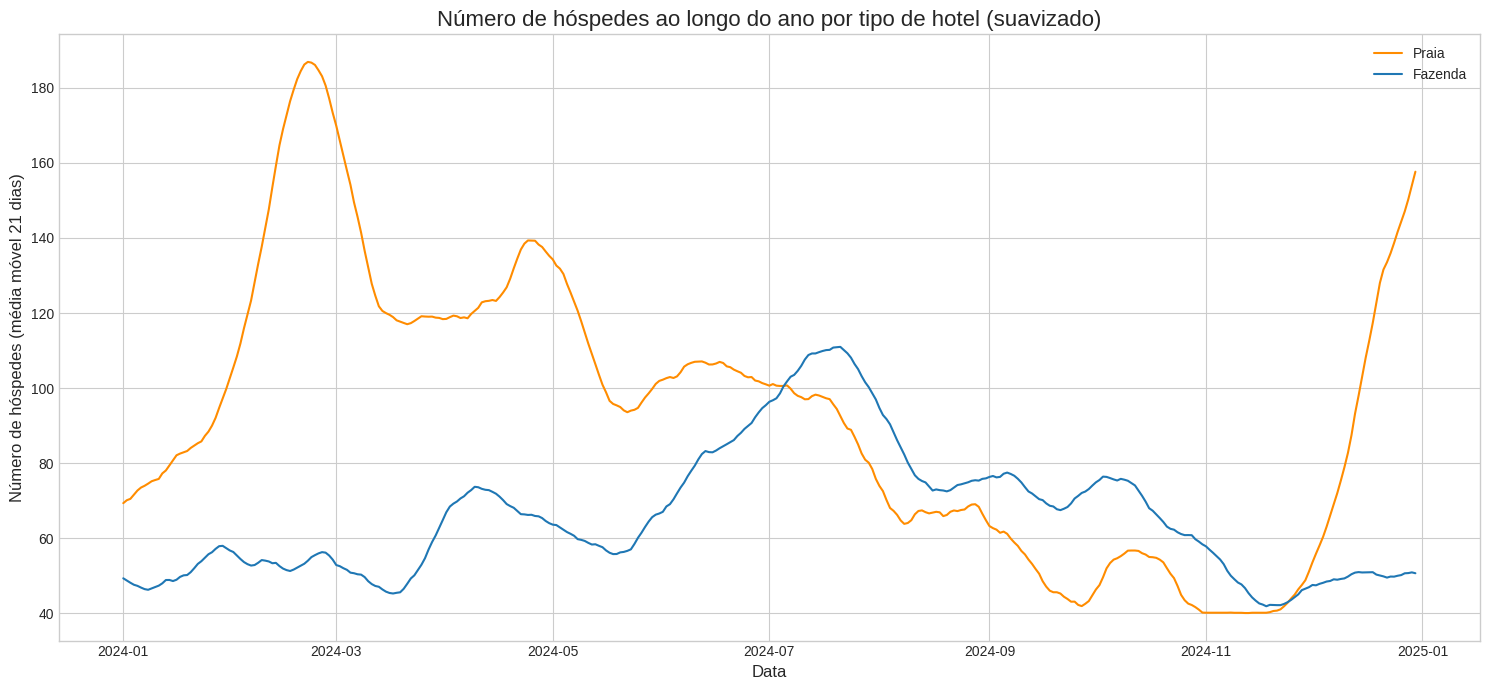

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Início: Bloco de Simulação de Dados ---
datas = pd.to_datetime(pd.date_range(start="2024-01-01", end="2024-12-31", freq='D'))
dias_do_ano = np.arange(1, len(datas) + 1)

def pico_gaussiano(dias, centro, largura, amplitude):
    return amplitude * np.exp(-((dias - centro)**2) / (2 * largura**2))

# Ciclo anual praia (hemisfério sul)
# Pico no verão: Dez (~dia 335) a Mar (~dia 90)
ciclo_praia = (
    40 * np.sin(2 * np.pi * (dias_do_ano - 20) / 365) +  # ciclo principal
    8 * np.sin(4 * np.pi * (dias_do_ano - 40) / 365) +   # harmônico para assimetria
    75                                                    # base alta para não chegar perto de zero
)

# Ciclo anual fazenda (menos sazonal, com picos em férias de julho)
ciclo_fazenda = (
    10 * np.sin(2 * np.pi * (dias_do_ano - 130) / 365) +
    3 * np.sin(4 * np.pi * (dias_do_ano - 200) / 365) +
    60                                                    # base mais alta para mínima garantida
)

# Eventos específicos
pico_carnaval_praia = pico_gaussiano(dias_do_ano, centro=55, largura=8, amplitude=90)   # carnaval mais forte
pico_julho_fazenda = pico_gaussiano(dias_do_ano, centro=195, largura=20, amplitude=45)  # férias de julho
pico_julho_praia = pico_gaussiano(dias_do_ano, centro=195, largura=20, amplitude=25)    # julho praia (menor)
pico_reveillon = pico_gaussiano(dias_do_ano, centro=365, largura=10, amplitude=110)     # reveillon mais forte

# Ruído autocorrelacionado
def ruido_ar1(n, phi=0.85, sigma=5):
    ruido = np.zeros(n)
    ruido[0] = np.random.normal(0, sigma)
    for i in range(1, n):
        ruido[i] = phi * ruido[i-1] + np.random.normal(0, sigma)
    return ruido

ruido_praia = ruido_ar1(len(datas), sigma=8)
ruido_fazenda = ruido_ar1(len(datas), sigma=6)

# Combinação final
hospedes_praia = ciclo_praia + pico_carnaval_praia + pico_julho_praia + pico_reveillon + ruido_praia
hospedes_fazenda = ciclo_fazenda + pico_julho_fazenda + ruido_fazenda

# Garantir mínimo absoluto (ex: 40 hóspedes)
hospedes_praia = np.maximum(hospedes_praia, 40)
hospedes_fazenda = np.maximum(hospedes_fazenda, 40)

# Criar DataFrame
df_group = pd.concat([
    pd.DataFrame({'data': datas, 'hotel_tipo': 'praia', 'hospedes': hospedes_praia}),
    pd.DataFrame({'data': datas, 'hotel_tipo': 'fazenda', 'hospedes': hospedes_fazenda})
])

# Média móvel 21 dias
df_group['media_movel'] = df_group.groupby('hotel_tipo')['hospedes'] \
                                  .transform(lambda x: x.rolling(window=21, center=True, min_periods=1).mean())

# Pivot e exportação
df_final = df_group.pivot_table(index='data', columns='hotel_tipo', values='media_movel') \
                   .rename(columns={'praia': 'ma_praia', 'fazenda': 'ma_fazenda'}) \
                   .dropna().head(365)

df_final.to_csv('medias_moveis_suavizadas.csv')
print(f"DataFrame com {len(df_final)} amostras exportado com sucesso para 'medias_moveis_suavizadas.csv'")
print(df_final.head())

# Gráfico
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 7))
plt.plot(df_final.index, df_final['ma_praia'], label='Praia', color='darkorange')
plt.plot(df_final.index, df_final['ma_fazenda'], label='Fazenda', color='tab:blue')
plt.title("Número de hóspedes ao longo do ano por tipo de hotel (suavizado)", fontsize=16)
plt.xlabel("Data", fontsize=12)
plt.ylabel("Número de hóspedes (média móvel 21 dias)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()
